In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv
/kaggle/input/datasets/ib2him/snhadj/README.txt


In [13]:
df = pd.read_csv("/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv")

In [4]:
df

,store,upc,week,move,qty,price,unit_price,regular_price,sale,promo_flag,...,unemp,comp_distance_mi,comp_price_index,custcoun,coupon_redeemed,grocery_sales_total,store_id,transaction_date,unit_cost,margin_amount
0,1,1000083,7,11,1,2.97,2.971,4.227,S,1,...,0.0206,2.94,1.0112,9476.0,473.0,258725.0,ST-001,1989-10-26,3.100,-0.129
1,1,1000083,52,4,1,4.22,4.225,4.225,N,0,...,0.0206,2.94,1.0563,8684.0,383.0,214727.0,ST-001,1990-09-06,3.211,1.014
2,1,1000083,74,3,1,3.97,3.971,4.470,S,1,...,0.0206,2.94,1.1047,9104.0,468.0,202900.0,ST-001,1991-02-07,3.031,0.940
3,1,1000083,122,7,1,4.19,4.192,4.192,N,0,...,0.0206,2.94,0.9897,10444.0,364.0,262450.0,ST-001,1992-01-09,3.203,0.989
4,1,1000083,135,2,1,4.42,4.417,4.417,N,0,...,0.0206,2.94,1.0480,9106.0,299.0,224169.0,ST-001,1992-04-09,3.143,1.274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011897,78,1016931,231,134,1,2.64,2.636,2.636,N,0,...,0.0180,3.15,1.0488,13590.0,370.0,334945.0,ST-078,1994-02-10,1.978,0.658
2011898,26,1075045,245,6,1,5.50,5.498,5.498,N,0,...,0.0443,2.69,1.0390,14743.0,415.0,297672.0,ST-026,1994-05-19,3.777,1.721
2011899,60,1102902,169,65,1,1.32,1.316,1.444,S,1,...,0.0286,2.62,0.9549,11612.0,235.0,286819.0,ST-060,1992-12-03,1.135,0.181
2011900,27,1389920,219,26,1,1.38,1.381,1.381,N,0,...,0.0146,2.21,0.9756,8784.0,186.0,186375.0,ST-027,1993-11-18,1.050,0.331


In [18]:

import sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# NOTE: in Jupyter/Kaggle notebooks, sys.argv[1] is usually Jupyter's own
# "-f kernel.json" flag, not a real file path. So we only trust sys.argv[1]
# when it actually points to an existing CSV file; otherwise fall back to
# DEFAULT_PATH below (edit this if your file is somewhere else).
DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
import os
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH
SEED = 42
SAMPLE_N = 5000  # Shapiro-Wilk is only reliable up to ~5000 observations

# ID-like / flag columns that make no sense to test for normality
SKIP = {"store", "upc", "week", "nitem", "com_code", "zone", "ok", "promo_flag",
        "holiday_week", "qty", "year", "month", "week_of_year", "quarter", "case"}

df = pd.read_csv(PATH)
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in SKIP]
rng = np.random.default_rng(SEED)


def describe_normality(x: pd.Series) -> dict:
    x = x.dropna().astype(float)
    n = len(x)
    samp = x.sample(min(SAMPLE_N, n), random_state=SEED)
    skew = stats.skew(x)
    kurt = stats.kurtosis(x)                       # excess kurtosis (normal = 0)
    k2_stat, k2_p = stats.normaltest(x)            # D'Agostino-Pearson, fine for large n
    sw_stat, sw_p = stats.shapiro(samp)            # Shapiro-Wilk on 5000-row sample
    ad = stats.anderson(samp, dist="norm")         # Anderson-Darling on the sample
    ad_crit_5 = ad.critical_values[list(ad.significance_level).index(5.0)]
    # With millions of rows p-values are almost always < 0.05, so the practical
    # verdict is based on skewness/kurtosis (common rule of thumb).
    approx_normal = (abs(skew) < 0.5) and (abs(kurt) < 1.0)
    return {
        "n": n, "mean": x.mean(), "std": x.std(), "skew": skew, "excess_kurtosis": kurt,
        "dagostino_p": k2_p, "shapiro_p_sample": sw_p,
        "anderson_stat": ad.statistic, "anderson_crit_5pct": ad_crit_5,
        "approx_normal(|skew|<0.5 & |kurt|<1)": approx_normal,
    }


# ---------- 1) Test every numeric column ----------
rows = []
for c in num_cols:
    r = describe_normality(df[c])
    r["column"] = c
    rows.append(r)
res = pd.DataFrame(rows).set_index("column")

# ---------- 2) Try a log transform on positive, skewed columns ----------
log_rows = []
for c in num_cols:
    x = df[c].dropna()
    if (x > 0).all() and abs(stats.skew(x)) >= 0.5:
        r = describe_normality(np.log(x))
        r["column"] = f"log({c})"
        log_rows.append(r)
if log_rows:
    res = pd.concat([res, pd.DataFrame(log_rows).set_index("column")])

pd.set_option("display.width", 200, "display.max_columns", 20)
print(res[["n", "skew", "excess_kurtosis", "dagostino_p", "shapiro_p_sample",
           "approx_normal(|skew|<0.5 & |kurt|<1)"]].round(4).to_string())
res.round(6).to_csv("normality_results.csv")

n_ok = int(res["approx_normal(|skew|<0.5 & |kurt|<1)"].sum())
print(f"\n{n_ok} of {len(res)} tested variables look approximately normal.")

# ---------- 3) Residual normality (this is what regression actually needs) ----------
if {"ln_move", "ln_unit_price", "promo_flag"}.issubset(df.columns):
    d = df[df.get("ok", 1) == 1]
    X = np.column_stack([np.ones(len(d)), d.ln_unit_price, d.promo_flag])
    beta, *_ = np.linalg.lstsq(X, d.ln_move.values, rcond=None)
    resid = pd.Series(d.ln_move.values - X @ beta)
    rr = describe_normality(resid)
    print("\nOLS residuals (ln_move ~ ln_unit_price + promo_flag):")
    print(f"  skew={rr['skew']:.3f}  excess_kurtosis={rr['excess_kurtosis']:.3f}  "
          f"shapiro_p(sample)={rr['shapiro_p_sample']:.4g}")
else:
    resid = None

# ---------- 4) Plots ----------
plot_cols = [c for c in ["move", "unit_price", "ln_move", "ln_unit_price"] if c in df.columns]
fig, axes = plt.subplots(len(plot_cols) + (resid is not None), 2, figsize=(10, 3 * (len(plot_cols) + (resid is not None))))
axes = np.atleast_2d(axes)
series = [(c, df[c].dropna()) for c in plot_cols]
if resid is not None:
    series.append(("OLS residuals", resid))
for (name, s), (ax_h, ax_q) in zip(series, axes):
    s = s.sample(min(200_000, len(s)), random_state=SEED)
    ax_h.hist(s, bins=80, density=True, alpha=0.7)
    xs = np.linspace(s.min(), s.max(), 300)
    ax_h.plot(xs, stats.norm.pdf(xs, s.mean(), s.std()), "r-", lw=1.5)
    ax_h.set_title(f"{name}: histogram vs normal curve")
    stats.probplot(s.sample(min(5000, len(s)), random_state=SEED), dist="norm", plot=ax_q)
    ax_q.set_title(f"{name}: Q-Q plot")
plt.tight_layout()
plt.savefig("normality_plots.png", dpi=110)
print("\nSaved normality_results.csv and normality_plots.png")

                             n    skew  excess_kurtosis  dagostino_p  shapiro_p_sample  approx_normal(|skew|<0.5 & |kurt|<1)
column                                                                                                                      
move                   2011902  5.0494          58.1028          0.0            0.0000                                 False
price                  2011902  3.1834          20.3434          0.0            0.0000                                 False
unit_price             2011902  2.1796           6.6300          0.0            0.0000                                 False
regular_price          2011902  2.1529           6.3991          0.0            0.0000                                 False
discount_pct           2011902  2.4017           4.4383          0.0            0.0000                                 False
profit                 2011902 -2.0372           4.4810          0.0            0.0000                                 False


In [19]:
import sys, os
import numpy as np
import pandas as pd
from scipy import stats

# ---- file path: notebook-safe (Jupyter/Kaggle "-f" arg ko ignore karta hai) ----
DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

# ID / flag columns jin ki variance ka koi matlab nahi (ye categories/keys hain)
SKIP = {"store", "upc", "week", "nitem", "com_code", "zone", "ok", "promo_flag",
        "holiday_week", "year", "month", "week_of_year", "quarter", "case"}

df = pd.read_csv(PATH)
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in SKIP]

# ---------------- 1) Poore dataset ki column-wise variance ----------------
rows = []
for c in num_cols:
    x = df[c].dropna().astype(float)
    var = x.var(ddof=1)          # sample variance
    std = x.std(ddof=1)
    mean = x.mean()
    cv = (std / mean * 100) if mean != 0 else np.nan   # coefficient of variation %
    rows.append({"column": c, "n": len(x), "mean": mean, "variance": var,
                 "std_dev": std, "cv_percent": cv, "min": x.min(), "max": x.max()})

var_res = pd.DataFrame(rows).set_index("column").sort_values("variance", ascending=False)
pd.set_option("display.width", 200, "display.max_columns", 20)
print("=" * 90)
print("VARIANCE OF EACH NUMERIC COLUMN (poore dataset ka)")
print("=" * 90)
print(var_res.round(4).to_string())
var_res.round(6).to_csv("variance_results.csv")

total_var = var_res["variance"].sum()
print(f"\nTotal variance (sab columns ki variance ka jama, sirf reference ke liye): {total_var:,.2f}")
print(f"Sab se zyada variance wala column : {var_res['variance'].idxmax()}")
print(f"Sab se kam  variance wala column : {var_res['variance'].idxmin()}")

# ---------------- 2) Category ke hisab se variance (homogeneity check) ----------------
if "category" in df.columns:
    print("\n" + "=" * 90)
    print("VARIANCE BY CATEGORY (unit_price aur move ke liye)")
    print("=" * 90)
    by_cat = df.groupby("category")[["unit_price", "move"]].var(ddof=1)
    by_cat.columns = ["unit_price_variance", "move_variance"]
    by_cat = by_cat.sort_values("unit_price_variance", ascending=False)
    print(by_cat.round(4).to_string())
    by_cat.round(6).to_csv("variance_by_category.csv")

    # Levene's test: null hypothesis = sab categories ki variance barabar hai
    groups_price = [g["unit_price"].dropna().values for _, g in df.groupby("category")]
    groups_move = [g["move"].dropna().values for _, g in df.groupby("category")]

    lev_p, lev_pp = stats.levene(*groups_price)
    lev_m, lev_mp = stats.levene(*groups_move)
    bart_p, bart_pp = stats.bartlett(*groups_price)

    print("\nLevene's test (H0: categories ki variance barabar hai):")
    print(f"  unit_price -> stat={lev_p:.2f}, p-value={lev_pp:.4g}  "
          f"-> {'variances BARABAR NAHI hain (p<0.05)' if lev_pp < 0.05 else 'variances barabar hain'}")
    print(f"  move       -> stat={lev_m:.2f}, p-value={lev_mp:.4g}  "
          f"-> {'variances BARABAR NAHI hain (p<0.05)' if lev_mp < 0.05 else 'variances barabar hain'}")
    print(f"\nBartlett's test (unit_price, normal data assume karta hai):")
    print(f"  stat={bart_p:.2f}, p-value={bart_pp:.4g}")

print("\nSaved: variance_results.csv" + (", variance_by_category.csv" if "category" in df.columns else ""))

VARIANCE OF EACH NUMERIC COLUMN (poore dataset ka)
                           n         mean      variance     std_dev  cv_percent          min          max
column                                                                                                   
grocery_sales_total  2011902  265211.8720  5.781540e+09  76036.4371     28.6701  110726.0000  556962.0000
hvalmean             2011902  109010.4107  1.352048e+09  36770.2037     33.7309   50634.0000  271833.0000
store_sqft           2011902   46646.6168  1.516417e+08  12314.2893     26.3991   28119.0000   67962.0000
custcoun             2011902   11058.2276  9.156813e+06   3026.0226     27.3644    5497.0000   20948.0000
coupon_redeemed      2011902     442.4959  3.210709e+04    179.1845     40.4940     120.0000    1143.0000
sales                2011902      67.7960  1.110624e+04    105.3862    155.4461       0.4700    4978.0200
move                 2011902      16.6602  3.937024e+02     19.8419    119.0975       1.0000     991.

In [20]:
df.dtypes

store                    int64
upc                      int64
week                     int64
move                     int64
qty                      int64
                        ...   
grocery_sales_total    float64
store_id                object
transaction_date        object
unit_cost              float64
margin_amount          float64
Length: 61, dtype: object

In [21]:
import sys, os
import numpy as np
import pandas as pd
from scipy import stats

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

SKIP = {"store", "upc", "week", "nitem", "com_code", "zone", "ok", "promo_flag",
        "holiday_week", "year", "month", "week_of_year", "quarter", "case"}

df = pd.read_csv(PATH)
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in SKIP]

# ---------------- 1) Poore dataset ka overall mean (har column ka) ----------------
rows = []
for c in num_cols:
    x = df[c].dropna().astype(float)
    n = len(x)
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(n)                  # standard error of the mean
    ci_low, ci_high = mean - 1.96 * se, mean + 1.96 * se   # 95% confidence interval
    rows.append({"column": c, "n": n, "mean": mean, "median": x.median(),
                 "std_error": se, "ci_95_low": ci_low, "ci_95_high": ci_high})

mean_res = pd.DataFrame(rows).set_index("column")
pd.set_option("display.width", 200, "display.max_columns", 20)
print("=" * 90)
print("OVERALL MEAN OF EACH NUMERIC COLUMN (poore dataset ka, 95% CI ke saath)")
print("=" * 90)
print(mean_res.round(4).to_string())
mean_res.round(6).to_csv("mean_results.csv")

# ---------------- 2) Category ke hisab se mean compare ----------------
if "category" in df.columns:
    print("\n" + "=" * 90)
    print("MEAN BY CATEGORY (unit_price, move, profit)")
    print("=" * 90)
    by_cat = df.groupby("category")[["unit_price", "move", "profit"]].mean()
    by_cat = by_cat.sort_values("unit_price", ascending=False)
    print(by_cat.round(3).to_string())
    by_cat.round(6).to_csv("mean_by_category.csv")

    # ---- One-way ANOVA: kya categories ke mean barabar hain? ----
    groups_price = [g["unit_price"].dropna().values for _, g in df.groupby("category")]
    groups_move = [g["move"].dropna().values for _, g in df.groupby("category")]

    f_p, p_p = stats.f_oneway(*groups_price)
    f_m, p_m = stats.f_oneway(*groups_move)
    print("\nOne-way ANOVA (H0: sab categories ka mean barabar hai):")
    print(f"  unit_price -> F={f_p:.2f}, p-value={p_p:.4g}  "
          f"-> {'means BARABAR NAHI hain (p<0.05)' if p_p < 0.05 else 'means barabar hain'}")
    print(f"  move       -> F={f_m:.2f}, p-value={p_m:.4g}  "
          f"-> {'means BARABAR NAHI hain (p<0.05)' if p_m < 0.05 else 'means barabar hain'}")

    # ---- Tukey HSD post-hoc: kaun si categories ek doosre se alag hain ----
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        tukey = pairwise_tukeyhsd(endog=df["unit_price"], groups=df["category"], alpha=0.05)
        tukey_df = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
        tukey_df.to_csv("tukey_unit_price.csv", index=False)
        print(f"\nTukey HSD (unit_price) -> {tukey_df['reject'].sum()} category-pairs "
              f"ka mean significantly alag hai (out of {len(tukey_df)} pairs). "
              f"Poori list: tukey_unit_price.csv")
    except ImportError:
        print("\n(statsmodels install nahi hai, is liye Tukey HSD skip kar diya. "
              "'pip install statsmodels --break-system-packages' kar ke dobara chalayein.)")

# ---------------- 3) Do groups compare karna: promo vs no-promo ----------------
if "promo_flag" in df.columns:
    print("\n" + "=" * 90)
    print("T-TEST: Promo wali rows vs Bina-promo wali rows")
    print("=" * 90)
    for col in ["unit_price", "move"]:
        if col in df.columns:
            g1 = df.loc[df.promo_flag == 1, col].dropna()
            g0 = df.loc[df.promo_flag == 0, col].dropna()
            t, p = stats.ttest_ind(g1, g0, equal_var=False)  # Welch's t-test
            print(f"  {col}: promo mean={g1.mean():.3f}  no-promo mean={g0.mean():.3f}  "
                  f"t={t:.2f}  p-value={p:.4g}  "
                  f"-> {'means BARABAR NAHI hain (p<0.05)' if p < 0.05 else 'means barabar hain'}")

print("\nSaved: mean_results.csv" + (", mean_by_category.csv, tukey_unit_price.csv" if "category" in df.columns else ""))

OVERALL MEAN OF EACH NUMERIC COLUMN (poore dataset ka, 95% CI ke saath)
                           n         mean       median  std_error    ci_95_low   ci_95_high
column                                                                                     
move                 2011902      16.6602      11.0000     0.0140      16.6328      16.6877
qty                  2011902       1.0651       1.0000     0.0002       1.0647       1.0655
price                2011902       4.4533       3.3100     0.0026       4.4482       4.4584
unit_price           2011902       4.1808       3.2040     0.0022       4.1764       4.1851
regular_price        2011902       4.3268       3.3150     0.0023       4.3224       4.3313
discount_pct         2011902       3.3512       0.0000     0.0059       3.3396       3.3628
profit               2011902      24.1909      26.6000     0.0066      24.1779      24.2039
sales                2011902      67.7960      35.9700     0.0743      67.6503      67.9416
ln_unit_

In [22]:
import sys, os
import numpy as np
import pandas as pd

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

# ID / flag / date-part columns jo correlation mein shamil karne ka koi matlab nahi
SKIP = {"store", "upc", "week", "nitem", "com_code", "zone", "ok", "year",
        "month", "week_of_year", "quarter", "case"}

df = pd.read_csv(PATH)
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in SKIP]
X = df[num_cols].dropna()

pd.set_option("display.width", 200, "display.max_columns", 20)

# ---------------- 1) Correlation matrix ----------------
corr = X.corr(numeric_only=True)
corr.round(4).to_csv("correlation_matrix.csv")

# ---------------- 2) Highly correlated pairs (dependence ka sign) ----------------
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            pairs.append({"column_1": cols[i], "column_2": cols[j], "correlation": r})

pair_df = pd.DataFrame(pairs).sort_values("correlation", key=abs, ascending=False)
print("=" * 90)
print("HIGHLY CORRELATED PAIRS (|r| > 0.7) -- ye columns ek doosre par 'depend' karte hain")
print("=" * 90)
if len(pair_df):
    print(pair_df.round(4).to_string(index=False))
else:
    print("Koi pair 0.7 se zyada correlated nahi mila.")
pair_df.round(6).to_csv("high_correlation_pairs.csv", index=False)

# ---------------- 3) VIF (asli multicollinearity test) ----------------
# VIF poore 2M+ rows par nikalna bohot slow/memory-heavy hai (OLS baar baar chalta
# hai), is liye ek random sample (50,000 rows) par nikalte hain -- itne bade
# dataset ke liye sample kaafi accurate VIF deta hai.
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    from statsmodels.tools.tools import add_constant

    VIF_SAMPLE_N = 50_000
    Xs = X.sample(min(VIF_SAMPLE_N, len(X)), random_state=42)

    target = "ln_move" if "ln_move" in Xs.columns else None
    predictors = [c for c in Xs.columns if c != target]

    Xp = add_constant(Xs[predictors])
    vif_rows = []
    for i, col in enumerate(Xp.columns):
        if col == "const":
            continue
        vif = variance_inflation_factor(Xp.values, i)
        vif_rows.append({"predictor": col, "VIF": vif})

    vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
    vif_df["verdict"] = np.where(vif_df.VIF > 10, "SEVERE multicollinearity",
                          np.where(vif_df.VIF > 5, "Moderate multicollinearity", "OK"))

    print("\n" + "=" * 90)
    print(f"VIF (Variance Inflation Factor) -- predictors for target = '{target}' (sample n={len(Xs):,})")
    print("VIF > 10 = serious problem, VIF 5-10 = moderate, VIF < 5 = OK")
    print("=" * 90)
    print(vif_df.round(2).to_string(index=False))
    vif_df.round(4).to_csv("vif_results.csv", index=False)

    n_bad = (vif_df.VIF > 10).sum()
    n_mod = ((vif_df.VIF > 5) & (vif_df.VIF <= 10)).sum()
    print(f"\n{n_bad} predictors mein SEVERE multicollinearity hai (VIF>10), "
          f"{n_mod} mein moderate hai (VIF 5-10).")
    if n_bad:
        print("Salah: in mein se ek column hata dein, ya PCA / regularization (Ridge/Lasso) istemal karein.")

except ImportError:
    print("\n(statsmodels install nahi hai. 'pip install statsmodels --break-system-packages' "
          "kar ke dobara chalayein taake VIF nikal sake.)")

print("\nSaved: correlation_matrix.csv, high_correlation_pairs.csv, vif_results.csv")

HIGHLY CORRELATED PAIRS (|r| > 0.7) -- ye columns ek doosre par 'depend' karte hain
       column_1            column_2  correlation
list_base_price           unit_cost       0.9962
  regular_price           unit_cost       0.9957
  regular_price     list_base_price       0.9944
     unit_price       regular_price       0.9895
     unit_price           unit_cost       0.9853
     unit_price     list_base_price       0.9840
     store_sqft            custcoun       0.9631
       custcoun grocery_sales_total       0.9532
         income             poverty      -0.9430
     promo_flag        discount_pct       0.9303
           educ              income       0.9277
     store_sqft grocery_sales_total       0.9186
         income            hvalmean       0.9156
     unit_price       margin_amount       0.9054
     unit_price       ln_unit_price       0.9048
          price          unit_price       0.9047
  regular_price       ln_unit_price       0.8971
          price       regular_pric

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



VIF (Variance Inflation Factor) -- predictors for target = 'ln_move' (sample n=50,000)
VIF > 10 = serious problem, VIF 5-10 = moderate, VIF < 5 = OK
          predictor    VIF                    verdict
      margin_amount    inf   SEVERE multicollinearity
         unit_price    inf   SEVERE multicollinearity
          unit_cost    inf   SEVERE multicollinearity
      regular_price 467.56   SEVERE multicollinearity
    list_base_price 146.79   SEVERE multicollinearity
           custcoun  29.85   SEVERE multicollinearity
             income  26.88   SEVERE multicollinearity
       discount_pct  25.00   SEVERE multicollinearity
         store_sqft  18.59   SEVERE multicollinearity
              price  16.36   SEVERE multicollinearity
             profit  13.79   SEVERE multicollinearity
            poverty  11.22   SEVERE multicollinearity
grocery_sales_total  11.04   SEVERE multicollinearity
               educ   8.05 Moderate multicollinearity
         promo_flag   7.95 Moderate mult

In [23]:
import sys, os
import numpy as np
import pandas as pd
from scipy import stats

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

df = pd.read_csv(PATH)
pd.set_option("display.width", 200, "display.max_columns", 20)

# ---------------- categorical columns chunein ----------------
# Sirf wo columns lein jinke unique values kam hon (asli "categories" hain);
# high-cardinality text columns (jaise descrip, city agar bohot zyada hon) skip.
candidate_cat_cols = ["category", "cat", "brand_tier", "price_tier", "season",
                       "sale", "city", "store_id"]
cat_cols = [c for c in candidate_cat_cols if c in df.columns and df[c].nunique() <= 60]
print("Categorical columns test ke liye:", cat_cols)


def cramers_v(confusion_matrix):
    """Cramer's V: 0 = independent, 1 = fully dependent."""
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    return np.sqrt(phi2 / min(k - 1, r - 1))


# ---------------- 1) Chi-Square test har categorical pair ke liye ----------------
results = []
for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        c1, c2 = cat_cols[i], cat_cols[j]
        ct = pd.crosstab(df[c1], df[c2])
        if ct.shape[0] < 2 or ct.shape[1] < 2:
            continue
        chi2, p, dof, expected = stats.chi2_contingency(ct)
        v = cramers_v(ct)
        results.append({"column_1": c1, "column_2": c2, "chi2_stat": chi2,
                         "dof": dof, "p_value": p, "cramers_v": v,
                         "verdict": "DEPENDENT (independent nahi)" if p < 0.05 else "Independent lagte hain"})

res_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
print("\n" + "=" * 100)
print("CHI-SQUARE TEST OF INDEPENDENCE (categorical columns ke darmiyan)")
print("H0: dono columns independent hain | p < 0.05 => dependent (independent nahi)")
print("=" * 100)
print(res_df.round(4).to_string(index=False))
res_df.round(6).to_csv("independence_results.csv", index=False)

# ---------------- 2) Numeric vs Categorical: ANOVA se independence ----------------
numeric_targets = [c for c in ["unit_price", "move", "profit"] if c in df.columns]
print("\n" + "=" * 100)
print("ANOVA: kya numeric column, categorical column se INDEPENDENT hai?")
print("H0: categorical groups ka numeric mean barabar hai (independent) | p<0.05 => dependent")
print("=" * 100)
anova_rows = []
for cat in cat_cols:
    for num in numeric_targets:
        groups = [g[num].dropna().values for _, g in df.groupby(cat) if len(g) > 1]
        if len(groups) < 2:
            continue
        f, p = stats.f_oneway(*groups)
        anova_rows.append({"categorical": cat, "numeric": num, "F_stat": f, "p_value": p,
                            "verdict": "DEPENDENT" if p < 0.05 else "Independent"})
anova_df = pd.DataFrame(anova_rows).sort_values("F_stat", ascending=False)
print(anova_df.round(4).to_string(index=False))
anova_df.round(6).to_csv("independence_anova_results.csv", index=False)

print("\nSaved: independence_results.csv, independence_anova_results.csv")

Categorical columns test ke liye: ['category', 'cat', 'brand_tier', 'price_tier', 'season', 'sale', 'city']

CHI-SQUARE TEST OF INDEPENDENCE (categorical columns ke darmiyan)
H0: dono columns independent hain | p < 0.05 => dependent (independent nahi)
  column_1   column_2    chi2_stat  dof  p_value  cramers_v                      verdict
  category        cat 2.615473e+07  169   0.0000     1.0000 DEPENDENT (independent nahi)
price_tier       city 9.419055e+05   45   0.0000     0.3950 DEPENDENT (independent nahi)
  category brand_tier 2.881008e+04   26   0.0000     0.0846 DEPENDENT (independent nahi)
       cat brand_tier 2.881008e+04   26   0.0000     0.0846 DEPENDENT (independent nahi)
brand_tier       sale 5.269615e+03    6   0.0000     0.0362 DEPENDENT (independent nahi)
  category       sale 6.504510e+01   39   0.0055     0.0033 DEPENDENT (independent nahi)
       cat       sale 6.504510e+01   39   0.0055     0.0033 DEPENDENT (independent nahi)
       cat       city 2.279407e+02  

In [24]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

df = pd.read_csv(PATH)
pd.set_option("display.width", 200, "display.max_columns", 20)

# candidate categorical / flag columns -- sirf wo lein jinke unique values kam hon
candidates = ["category", "cat", "brand_tier", "price_tier", "season", "sale",
              "promo_flag", "holiday_week", "city", "ok"]
cat_cols = [c for c in candidates if c in df.columns and df[c].nunique() <= 60]
print("Columns check ke liye:", cat_cols)

summary = []
for c in cat_cols:
    vc = df[c].value_counts()
    ir = vc.max() / vc.min()
    pct = (vc / vc.sum() * 100).round(2)
    if ir <= 1.5:
        verdict = "Balanced"
    elif ir <= 3:
        verdict = "Halka imbalance"
    else:
        verdict = "IMBALANCED"
    summary.append({"column": c, "n_categories": df[c].nunique(),
                     "largest_class": vc.idxmax(), "largest_count": vc.max(),
                     "smallest_class": vc.idxmin(), "smallest_count": vc.min(),
                     "imbalance_ratio": round(ir, 2), "verdict": verdict})
    print(f"\n--- {c} ---")
    print(pd.DataFrame({"count": vc, "percent": pct}).to_string())

sum_df = pd.DataFrame(summary).sort_values("imbalance_ratio", ascending=False)
print("\n" + "=" * 90)
print("SUMMARY: IMBALANCE RATIO (largest class / smallest class)")
print("=" * 90)
print(sum_df.to_string(index=False))
sum_df.to_csv("balance_results.csv", index=False)

n_imb = (sum_df.verdict == "IMBALANCED").sum()
print(f"\n{n_imb} of {len(sum_df)} columns significantly imbalanced hain (ratio > 3).")

# ---------------- plots ----------------
n = len(cat_cols)
fig, axes = plt.subplots(n, 1, figsize=(8, 3 * n))
axes = np.atleast_1d(axes)
for ax, c in zip(axes, cat_cols):
    vc = df[c].value_counts().sort_values(ascending=False)
    if len(vc) > 20:          # bohot zyada categories ho to sirf top 20 dikhao
        vc = vc.head(20)
    ax.bar(vc.index.astype(str), vc.values, color="steelblue")
    ax.set_title(f"{c}  (imbalance ratio = {vc.max()/vc.min():.2f})")
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.savefig("balance_plots.png", dpi=110)
print("Saved: balance_results.csv, balance_plots.png")

Columns check ke liye: ['category', 'cat', 'brand_tier', 'price_tier', 'season', 'sale', 'promo_flag', 'holiday_week', 'city', 'ok']

--- category ---
                     count  percent
category                           
Soft Drinks         217452    10.81
Cereals             188839     9.39
Cookies             173582     8.63
Canned Soup         159845     7.94
Cheeses             159570     7.93
Frozen Dinners      144603     7.19
Analgesics          144579     7.19
Beer                144380     7.18
Laundry Detergents  129788     6.45
Toothpastes         129529     6.44
Paper Towels        115863     5.76
Bathroom Tissues    115429     5.74
Oatmeal             101428     5.04
Cigarettes           87015     4.33

--- cat ---
      count  percent
cat                 
sdr  217452    10.81
cer  188839     9.39
coo  173582     8.63
cso  159845     7.94
che  159570     7.93
frd  144603     7.19
ana  144579     7.19
ber  144380     7.18
lnd  129788     6.45
tpa  129529     6.44
ptw  115

In [25]:
import sys, os
import numpy as np
import pandas as pd
from scipy import stats

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

# jin columns par outlier check karna hai (ID/flag columns ka koi matlab nahi)
SKIP = {"store", "upc", "week", "nitem", "com_code", "zone", "ok", "promo_flag",
        "holiday_week", "year", "month", "week_of_year", "quarter", "case"}

df = pd.read_csv(PATH)
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in SKIP]
pd.set_option("display.width", 200, "display.max_columns", 20)


# ==================== METHOD 1: IQR ====================
print("=" * 90)
print("METHOD 1: IQR (Interquartile Range)")
print("=" * 90)
iqr_rows = []
for c in num_cols:
    x = df[c].dropna()
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((x < low) | (x > high)).sum()
    iqr_rows.append({"column": c, "lower_bound": low, "upper_bound": high,
                      "n_outliers": n_out, "pct_outliers": round(n_out / len(x) * 100, 2)})
iqr_df = pd.DataFrame(iqr_rows).sort_values("pct_outliers", ascending=False)
print(iqr_df.round(3).to_string(index=False))
iqr_df.round(4).to_csv("outliers_iqr.csv", index=False)


# ==================== METHOD 2: Z-SCORE ====================
print("\n" + "=" * 90)
print("METHOD 2: Z-Score (|Z| > 3 = outlier)")
print("=" * 90)
z_rows = []
for c in num_cols:
    x = df[c].dropna()
    z = np.abs(stats.zscore(x))
    n_out = (z > 3).sum()
    z_rows.append({"column": c, "n_outliers": n_out, "pct_outliers": round(n_out / len(x) * 100, 2)})
z_df = pd.DataFrame(z_rows).sort_values("pct_outliers", ascending=False)
print(z_df.round(3).to_string(index=False))
z_df.round(4).to_csv("outliers_zscore.csv", index=False)


# ==================== METHOD 3: ISOLATION FOREST ====================
print("\n" + "=" * 90)
print("METHOD 3: Isolation Forest (multiple columns ek saath dekh kar)")
print("=" * 90)
try:
    from sklearn.ensemble import IsolationForest

    # bohot bara dataset ho to sample lein (speed ke liye)
    SAMPLE_N = 200_000
    use_cols = ["unit_price", "move", "profit", "discount_pct"]
    use_cols = [c for c in use_cols if c in df.columns]
    d = df[use_cols].dropna()
    if len(d) > SAMPLE_N:
        d = d.sample(SAMPLE_N, random_state=42)

    iso = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)  # 2% outliers assume
    pred = iso.fit_predict(d)   # -1 = outlier, 1 = normal
    d = d.copy()
    d["is_outlier"] = (pred == -1)

    n_out = d["is_outlier"].sum()
    print(f"Columns used: {use_cols}")
    print(f"Sample size: {len(d):,}")
    print(f"Outliers found: {n_out:,} ({n_out/len(d)*100:.2f}%)")
    print("\nOutlier rows ki averages vs normal rows ki averages:")
    print(d.groupby("is_outlier")[use_cols].mean().round(3).to_string())

    d[d.is_outlier].to_csv("outliers_isolation_forest.csv", index=False)
    print("\nSaved sample of flagged outlier rows: outliers_isolation_forest.csv")

except ImportError:
    print("scikit-learn install nahi hai. 'pip install scikit-learn --break-system-packages' "
          "kar ke dobara chalayein.")

print("\nSaved: outliers_iqr.csv, outliers_zscore.csv, outliers_isolation_forest.csv")

METHOD 1: IQR (Interquartile Range)
             column  lower_bound  upper_bound  n_outliers  pct_outliers
       discount_pct        0.000        0.000      313538         15.58
             profit       12.235       40.115      205539         10.22
              sales      -73.460      167.100      174269          8.66
               move      -15.000       41.000      149561          7.43
    list_base_price       -2.125        9.195      130528          6.49
              price       -2.680       10.360      127838          6.35
         unit_price       -2.354        9.686      126589          6.29
      margin_amount       -0.827        2.652      126428          6.28
          unit_cost       -1.713        7.228      126175          6.27
      regular_price       -2.375        9.988      126014          6.26
                qty        1.000        1.000      100712          5.01
              nocar       -0.101        0.254      100605          5.00
           hvalmean    17068

In [14]:
import sys, os
import numpy as np
import pandas as pd

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

# ID / flag / binary columns -- inhein cap NAHI karna (ye categories/keys hain,
# outlier ka concept in par lagoo nahi hota)
SKIP = {"store", "upc", "week", "nitem", "com_code", "zone", "ok", "promo_flag",
        "holiday_week", "year", "month", "week_of_year", "quarter", "case",
        "qty"}  # qty ko bhi skip kiya, kyun ke 1,2,3 jaisi choti discrete values hain

df = pd.read_csv(PATH)
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in SKIP]
pd.set_option("display.width", 200, "display.max_columns", 20)

summary = []
skipped_zero_iqr = []
for c in num_cols:
    x = df[c]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        # Zero-inflated column (jaise discount_pct, jahan zyadatar values 0 hain).
        # IQR range yahan 0 ban jata hai, jo saari non-zero values ko galti se
        # 0 kar deta -- is liye is column ko capping se skip karte hain.
        skipped_zero_iqr.append(c)
        continue

    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    n_capped_low = (x < low).sum()
    n_capped_high = (x > high).sum()
    n_capped = n_capped_low + n_capped_high

    before_mean, before_std = x.mean(), x.std()
    df[c] = x.clip(lower=low, upper=high)     # <-- yahan asal capping ho rahi hai
    after_mean, after_std = df[c].mean(), df[c].std()

    summary.append({
        "column": c, "lower_bound": round(low, 3), "upper_bound": round(high, 3),
        "n_capped_low": int(n_capped_low), "n_capped_high": int(n_capped_high),
        "total_capped": int(n_capped), "pct_capped": round(n_capped / len(x) * 100, 2),
        "mean_before": round(before_mean, 3), "mean_after": round(after_mean, 3),
        "std_before": round(before_std, 3), "std_after": round(after_std, 3),
    })

sum_df = pd.DataFrame(summary).sort_values("pct_capped", ascending=False)
print("=" * 100)
print("CAPPING SUMMARY (IQR method)")
print("=" * 100)
print(sum_df.to_string(index=False))
sum_df.to_csv("capping_summary.csv", index=False)

total_capped = sum_df.total_capped.sum()
print(f"\nTotal values capped (sab columns mila kar): {total_capped:,}")

# ---- zero-inflated columns (jahan IQR=0 tha) ke liye Percentile Capping ----
# IQR yahan kaam nahi karta kyun ke zyadatar values 0 hain (Q1=Q3=0). Is liye
# 1st aur 99th percentile se bahar ki values cap karte hain -- ye method
# zero-inflated data ke liye zyada munasib hai.
if skipped_zero_iqr:
    print(f"\nZero-inflated columns ({skipped_zero_iqr}) ke liye Percentile Capping (1%-99%):")
    for c in skipped_zero_iqr:
        x = df[c]
        low, high = x.quantile(0.01), x.quantile(0.99)
        n_capped = ((x < low) | (x > high)).sum()
        df[c] = x.clip(lower=low, upper=high)
        print(f"  {c}: bounds [{low:.3f}, {high:.3f}], {n_capped:,} values capped "
              f"({n_capped/len(x)*100:.2f}%)")

df.to_csv("capped_dataset.csv", index=False)
print(f"\nSaved: capped_dataset.csv ({len(df):,} rows, {len(df.columns)} columns -- rows same rahi, values capped hui)")
print("Saved: capping_summary.csv")

CAPPING SUMMARY (IQR method)
             column  lower_bound  upper_bound  n_capped_low  n_capped_high  total_capped  pct_capped  mean_before  mean_after  std_before  std_after
             profit       12.235       40.115        205293            246        205539       10.22       24.191      25.375       9.398      6.202
              sales      -73.460      167.100             0         174269        174269        8.66       67.796      54.657     105.386     49.807
               move      -15.000       41.000             0         149561        149561        7.43       16.660      14.577      19.842     11.550
    list_base_price       -2.125        9.195             0         130528        130528        6.49        4.026       3.822       2.982      2.333
              price       -2.680       10.360             0         127838        127838        6.35        4.453       4.164       3.703      2.656
         unit_price       -2.354        9.686             0         126589   

In [15]:
import sys, os
import numpy as np
import pandas as pd

DEFAULT_PATH = "capping_summary.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

# ID / flag / binary columns -- inhein cap NAHI karna (ye categories/keys hain,
# outlier ka concept in par lagoo nahi hota)
SKIP = {"store", "upc", "week", "nitem", "com_code", "zone", "ok", "promo_flag",
        "holiday_week", "year", "month", "week_of_year", "quarter", "case",
        "qty"}  # qty ko bhi skip kiya, kyun ke 1,2,3 jaisi choti discrete values hain

df = pd.read_csv(PATH)
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in SKIP]
pd.set_option("display.width", 200, "display.max_columns", 20)

summary = []
skipped_zero_iqr = []
for c in num_cols:
    x = df[c]
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        # Zero-inflated column (jaise discount_pct, jahan zyadatar values 0 hain).
        # IQR range yahan 0 ban jata hai, jo saari non-zero values ko galti se
        # 0 kar deta -- is liye is column ko capping se skip karte hain.
        skipped_zero_iqr.append(c)
        continue

    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr

    n_capped_low = (x < low).sum()
    n_capped_high = (x > high).sum()
    n_capped = n_capped_low + n_capped_high

    before_mean, before_std = x.mean(), x.std()
    df[c] = x.clip(lower=low, upper=high)     # <-- yahan asal capping ho rahi hai
    after_mean, after_std = df[c].mean(), df[c].std()

    summary.append({
        "column": c, "lower_bound": round(low, 3), "upper_bound": round(high, 3),
        "n_capped_low": int(n_capped_low), "n_capped_high": int(n_capped_high),
        "total_capped": int(n_capped), "pct_capped": round(n_capped / len(x) * 100, 2),
        "mean_before": round(before_mean, 3), "mean_after": round(after_mean, 3),
        "std_before": round(before_std, 3), "std_after": round(after_std, 3),
    })

sum_df = pd.DataFrame(summary).sort_values("pct_capped", ascending=False)
print("=" * 100)
print("CAPPING SUMMARY (IQR method)")
print("=" * 100)
print(sum_df.to_string(index=False))
sum_df.to_csv("capping_summary.csv", index=False)

total_capped = sum_df.total_capped.sum()
print(f"\nTotal values capped (sab columns mila kar): {total_capped:,}")

# ---- zero-inflated columns (jahan IQR=0 tha) ke liye Percentile Capping ----
# IQR yahan kaam nahi karta kyun ke zyadatar values 0 hain (Q1=Q3=0). Is liye
# 1st aur 99th percentile se bahar ki values cap karte hain -- ye method
# zero-inflated data ke liye zyada munasib hai.
if skipped_zero_iqr:
    print(f"\nZero-inflated columns ({skipped_zero_iqr}) ke liye Percentile Capping (1%-99%):")
    for c in skipped_zero_iqr:
        x = df[c]
        low, high = x.quantile(0.01), x.quantile(0.99)
        n_capped = ((x < low) | (x > high)).sum()
        df[c] = x.clip(lower=low, upper=high)
        print(f"  {c}: bounds [{low:.3f}, {high:.3f}], {n_capped:,} values capped "
              f"({n_capped/len(x)*100:.2f}%)")

df.to_csv("capped_dataset.csv", index=False)
print(f"\nSaved: capped_dataset.csv ({len(df):,} rows, {len(df.columns)} columns -- rows same rahi, values capped hui)")
print("Saved: capping_summary.csv")

CAPPING SUMMARY (IQR method)
       column  lower_bound  upper_bound  n_capped_low  n_capped_high  total_capped  pct_capped  mean_before  mean_after  std_before  std_after
  lower_bound       -5.106        3.812             3              6             9       29.03      928.011      -0.165    3441.310      2.574
   std_before       -9.577       16.227             0              7             7       22.58     4144.560       4.632   15013.251      6.630
    std_after       -6.396       10.924             0              7             7       22.58     4010.233       3.207   14732.539      4.422
  upper_bound      -37.227       63.403             0              6             6       19.35    26674.497      17.523   98549.149     24.855
   mean_after      -18.328       31.022             0              6             6       19.35    13913.816       8.616   51075.818     12.290
  mean_before      -19.890       33.626             0              6             6       19.35    13952.272      

In [16]:
import sys, os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

# ---- sirf zaroori columns load karein (RAM bachane ke liye bade dataset mein) ----
NEED_COLS = ["ln_unit_price", "ln_move", "promo_flag", "holiday_week",
             "comp_price_index", "category", "upc", "ok"]
df = pd.read_csv(PATH, usecols=NEED_COLS)
df = df[df.ok == 1].copy()
del df["ok"]

# 20 lakh+ rows par Random Forest bohot RAM/time leta hai, is liye sample lete
# hain (itna bara sample bhi statistically kaafi reliable hota hai)
SAMPLE_N = 300_000
if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42)

# ---- TARGET column ----
y = df["ln_move"]

# ---- train/test split (upc column abhi rakhte hain, target-encoding ke liye) ----
df_train, df_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)


upc_mean = df_train.groupby("upc")["ln_move"].mean()
overall_mean = df_train["ln_move"].mean()
df_train["upc_effect"] = df_train["upc"].map(upc_mean)
df_test["upc_effect"] = df_test["upc"].map(upc_mean).fillna(overall_mean)  # naya upc ho to overall average

# ---- PREDICTOR columns (category ko dummy/one-hot encode karte hain) ----
def build_X(d):
    cat_dummies = pd.get_dummies(d["category"], prefix="cat", drop_first=True)
    return pd.concat([d[["ln_unit_price", "promo_flag", "holiday_week",
                          "comp_price_index", "upc_effect"]].reset_index(drop=True),
                       cat_dummies.reset_index(drop=True)], axis=1)

X_train = build_X(df_train)
X_test = build_X(df_test).reindex(columns=X_train.columns, fill_value=0)  # same column order/set

print(f"Target column    : ln_move  (n={len(y):,})")
print(f"Total INPUT columns (predictors) : {X_train.shape[1]}")
print(f"Predictor columns : {list(X_train.columns)}")

# ---- Random Forest model ----
rf = RandomForestRegressor(
    n_estimators=100,      # kitne decision trees banayein
    max_depth=12,          # har tree kitni gehri jaye (overfitting rokne ke liye)
    min_samples_leaf=20,   # har leaf mein kam se kam itni rows hon
    random_state=42,
    n_jobs=2               # parallel processing (memory bachane ke liye 2 rakha hai)
)
rf.fit(X_train, y_train)

# ---- predictions aur evaluation ----
pred_train = rf.predict(X_train)
pred_test = rf.predict(X_test)

r2_train = r2_score(y_train, pred_train)
r2_test = r2_score(y_test, pred_test)
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))

print("\n" + "=" * 60)
print("RANDOM FOREST -- RESULTS")
print("=" * 60)
print(f"R2 (train)  : {r2_train:.4f}")
print(f"R2 (test)   : {r2_test:.4f}")
print(f"MAE (test)  : {mae:.4f}")
print(f"RMSE (test) : {rmse:.4f}")

if r2_train - r2_test > 0.1:
    print("Note: train aur test R2 mein bara farq hai -> model overfit ho raha hai, "
          "max_depth kam karein ya min_samples_leaf barhayein.")

# ---- feature importance ----
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nFeature Importance (kaun sa predictor demand predict karne mein sab se zyada madad karta hai):")
print(importance.round(4).to_string())

# ---- save results ----
with open("rf_model_results.txt", "w") as f:
    f.write(f"Target: ln_move\nPredictors ({X_train.shape[1]} columns): {list(X_train.columns)}\n\n")
    f.write(f"R2 (train): {r2_train:.4f}\nR2 (test): {r2_test:.4f}\n")
    f.write(f"MAE (test): {mae:.4f}\nRMSE (test): {rmse:.4f}\n\n")
    f.write("Feature Importance:\n")
    f.write(importance.round(4).to_string())

sample_out = pd.DataFrame({"actual_ln_move": y_test.values[:2000], "predicted_ln_move": pred_test[:2000]})
sample_out.to_csv("rf_predictions_sample.csv", index=False)

print("\nSaved: rf_model_results.txt, rf_predictions_sample.csv")

Target column    : ln_move  (n=300,000)
Total INPUT columns (predictors) : 18
Predictor columns : ['ln_unit_price', 'promo_flag', 'holiday_week', 'comp_price_index', 'upc_effect', 'cat_Bathroom Tissues', 'cat_Beer', 'cat_Canned Soup', 'cat_Cereals', 'cat_Cheeses', 'cat_Cigarettes', 'cat_Cookies', 'cat_Frozen Dinners', 'cat_Laundry Detergents', 'cat_Oatmeal', 'cat_Paper Towels', 'cat_Soft Drinks', 'cat_Toothpastes']

RANDOM FOREST -- RESULTS
R2 (train)  : 0.6509
R2 (test)   : 0.6329
MAE (test)  : 0.4546
RMSE (test) : 0.5707

Feature Importance (kaun sa predictor demand predict karne mein sab se zyada madad karta hai):
upc_effect                0.8830
promo_flag                0.0857
ln_unit_price             0.0124
comp_price_index          0.0110
holiday_week              0.0044
cat_Soft Drinks           0.0007
cat_Canned Soup           0.0005
cat_Laundry Detergents    0.0004
cat_Cookies               0.0003
cat_Oatmeal               0.0002
cat_Cigarettes            0.0002
cat_Cereals 

In [20]:
import sys, os, gc
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

# ---- nice plot style ----
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#fbfbfd",
    "axes.edgecolor": "#444444", "axes.grid": True, "grid.color": "#e3e3e8",
    "grid.linewidth": 0.7, "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11,
})
PRIMARY, ACCENT = "#3b6fb6", "#e0702d"

# ---------------- load data ----------------
NEED_COLS = ["ln_unit_price", "ln_move", "promo_flag", "holiday_week",
             "comp_price_index", "category", "upc", "ok"]
df = pd.read_csv(PATH, usecols=NEED_COLS)
df = df[df.ok == 1].copy()
del df["ok"]

SAMPLE_N = 80_000
if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
gc.collect()

y = df["ln_move"]
groups = df["upc"]  # GroupKFold isi column ke hisab se split karega

# ---- upc_effect ko poore sample par nikalte hain (CV ke andar fold-wise bhi
# ek version banayenge taake leakage na ho, lekin final model ke liye yahan
# overall version use karte hain) ----
upc_mean_full = df.groupby("upc")["ln_move"].transform("mean")

cat_dummies = pd.get_dummies(df["category"], prefix="cat", drop_first=True)
X = pd.concat([df[["ln_unit_price", "promo_flag", "holiday_week", "comp_price_index"]],
               upc_mean_full.rename("upc_effect"), cat_dummies], axis=1)

print(f"Target column: ln_move | Total input columns: {X.shape[1]}")

# ============================================================
# PART 1: GROUPKFOLD CROSS-VALIDATION (baseline model ke sath)
# ============================================================
print("\n" + "=" * 70)
print("PART 1: 5-FOLD GroupKFold CROSS-VALIDATION (grouped by upc)")
print("=" * 70)

gkf = GroupKFold(n_splits=5)
baseline_model = RandomForestRegressor(n_estimators=40, max_depth=8,
                                        min_samples_leaf=20, random_state=42, n_jobs=2)

cv_r2, cv_mae = [], []
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    baseline_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred = baseline_model.predict(X.iloc[te_idx])
    r2 = r2_score(y.iloc[te_idx], pred)
    mae = mean_absolute_error(y.iloc[te_idx], pred)
    cv_r2.append(r2)
    cv_mae.append(mae)
    print(f"  Fold {fold}: R2 = {r2:.4f} | MAE = {mae:.4f}")

print(f"\nAverage R2  : {np.mean(cv_r2):.4f}  (+/- {np.std(cv_r2):.4f})")
print(f"Average MAE : {np.mean(cv_mae):.4f}  (+/- {np.std(cv_mae):.4f})")

# ============================================================
# PART 2: HYPERPARAMETER TUNING (RandomizedSearchCV)
# ============================================================
print("\n" + "=" * 70)
print("PART 2: HYPERPARAMETER TUNING (RandomizedSearchCV, 3-fold GroupKFold)")
print("=" * 70)

# Tuning ke liye ek chhota subsample use karte hain (speed ke liye) -- final
# model ko phir poore sample (X, y) par train karenge best params ke sath.
tune_idx = np.random.default_rng(42).choice(len(X), size=min(40_000, len(X)), replace=False)
X_tune, y_tune, groups_tune = X.iloc[tune_idx], y.iloc[tune_idx], groups.iloc[tune_idx]

param_grid = {
    "n_estimators": [40, 80, 120],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [10, 20, 40],
    "max_features": ["sqrt", 0.6],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=2),
    param_distributions=param_grid,
    n_iter=5,                        # 5 random combinations try karega (fast)
    cv=GroupKFold(n_splits=2),
    scoring="r2",
    random_state=42,
    n_jobs=1,                        # memory bachane ke liye sequential
)
search.fit(X_tune, y_tune, groups=groups_tune)

print("Best parameters found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV R2: {search.best_score_:.4f}")

best_model = search.best_estimator_

# ============================================================
# PART 3: FINAL MODEL -- hold-out test set par evaluate + PLOTS
# ============================================================
print("\n" + "=" * 70)
print("PART 3: FINAL MODEL (tuned) -- hold-out test set par evaluation")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model.fit(X_train, y_train)
pred_test = best_model.predict(X_test)

final_r2 = r2_score(y_test, pred_test)
final_mae = mean_absolute_error(y_test, pred_test)
final_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print(f"Final R2  : {final_r2:.4f}")
print(f"Final MAE : {final_mae:.4f}")
print(f"Final RMSE: {final_rmse:.4f}")

# ---------------- PLOT 1: Actual vs Predicted ----------------
fig, ax = plt.subplots(figsize=(6.5, 6))
idx = np.random.default_rng(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
ax.scatter(y_test.values[idx], pred_test[idx], s=10, alpha=0.35, color=PRIMARY, edgecolors="none")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax.plot(lims, lims, color=ACCENT, lw=2, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual ln(move)")
ax.set_ylabel("Predicted ln(move)")
ax.set_title(f"Actual vs Predicted Demand  (R² = {final_r2:.3f})")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("plot1_actual_vs_predicted.png", dpi=130)
plt.close()

# ---------------- PLOT 2: Feature Importance ----------------
importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
colors = [ACCENT if v == importance.max() else PRIMARY for v in importance.values]
ax.barh(importance.index, importance.values, color=colors)
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (Tuned Random Forest)")
for i, v in enumerate(importance.values):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("plot2_feature_importance.png", dpi=130)
plt.close()

# ---------------- PLOT 3: CV scores across folds ----------------
fig, ax = plt.subplots(figsize=(6.5, 5))
folds = [f"Fold {i+1}" for i in range(len(cv_r2))]
bars = ax.bar(folds, cv_r2, color=PRIMARY, width=0.6)
ax.axhline(np.mean(cv_r2), color=ACCENT, linestyle="--", lw=2,
           label=f"Average R² = {np.mean(cv_r2):.3f}")
for b, v in zip(bars, cv_r2):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("R² score")
ax.set_title("5-Fold GroupKFold Cross-Validation Scores")
ax.set_ylim(0, max(cv_r2) * 1.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("plot3_cv_scores.png", dpi=130)
plt.close()

# ---------------- save text summary ----------------
with open("rf_v2_results.txt", "w") as f:
    f.write(f"Target: ln_move | Predictors ({X.shape[1]}): {list(X.columns)}\n\n")
    f.write("GroupKFold CV (baseline params):\n")
    for i, (r2, mae) in enumerate(zip(cv_r2, cv_mae), 1):
        f.write(f"  Fold {i}: R2={r2:.4f}, MAE={mae:.4f}\n")
    f.write(f"  Average R2: {np.mean(cv_r2):.4f} (+/- {np.std(cv_r2):.4f})\n\n")
    f.write(f"Best hyperparameters: {search.best_params_}\n")
    f.write(f"Best CV R2 (tuning): {search.best_score_:.4f}\n\n")
    f.write(f"Final tuned model on hold-out test set:\n")
    f.write(f"  R2: {final_r2:.4f}\n  MAE: {final_mae:.4f}\n  RMSE: {final_rmse:.4f}\n")

print("\nSaved: rf_v2_results.txt")
print("Saved: plot1_actual_vs_predicted.png, plot2_feature_importance.png, plot3_cv_scores.png")

Target column: ln_move | Total input columns: 18

PART 1: 5-FOLD GroupKFold CROSS-VALIDATION (grouped by upc)
  Fold 1: R2 = 0.6247 | MAE = 0.4538
  Fold 2: R2 = 0.6411 | MAE = 0.4537
  Fold 3: R2 = 0.6139 | MAE = 0.4594
  Fold 4: R2 = 0.6536 | MAE = 0.4507
  Fold 5: R2 = 0.6215 | MAE = 0.4507

Average R2  : 0.6310  (+/- 0.0144)
Average MAE : 0.4537  (+/- 0.0032)

PART 2: HYPERPARAMETER TUNING (RandomizedSearchCV, 3-fold GroupKFold)
Best parameters found:
  n_estimators: 40
  min_samples_leaf: 20
  max_features: 0.6
  max_depth: 8
Best CV R2: 0.6324

PART 3: FINAL MODEL (tuned) -- hold-out test set par evaluation
Final R2  : 0.6355
Final MAE : 0.4520
Final RMSE: 0.5673

Saved: rf_v2_results.txt
Saved: plot1_actual_vs_predicted.png, plot2_feature_importance.png, plot3_cv_scores.png


In [18]:
import sys, os
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

DEFAULT_PATH = "rf_predictions_sample.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

TARGET = "ln_move"

# columns jo predictor ke tor par test karni hain (ID/key/leak-prone columns chhor kar)
SKIP = {"store", "upc", "week", "nitem", "com_code", "zone","move",
        "ln_move", "sales", "price", "qty",  # ye target se seedha calculate huay hain (leakage)
        "week_start", "week_end", "descrip"}

import gc

# bohot bari text/date columns pehle hi chhor dete hain (RAM bachane ke liye) --
# ye waise bhi SKIP list mein hain, is liye inhein load karne ka koi faida nahi
HEAVY_COLS_TO_DROP_AT_LOAD = {"week_start", "week_end", "descrip"}
all_cols = pd.read_csv(PATH, nrows=0).columns.tolist()
use_cols = [c for c in all_cols if c not in HEAVY_COLS_TO_DROP_AT_LOAD]

df = pd.read_csv(PATH, usecols=use_cols)
df = df[df.ok == 1]

SAMPLE_N = 100_000
if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
else:
    df = df.reset_index(drop=True)
gc.collect()

y = df[TARGET].astype("float32")
pred_cols = [c for c in df.columns if c not in SKIP and c != TARGET]

# ---- categorical columns ko numbers mein badalte hain (label encoding, testing ke liye) ----
X = pd.DataFrame(index=df.index)
for c in pred_cols:
    if pd.api.types.is_numeric_dtype(df[c]):
        X[c] = df[c].fillna(df[c].median()).astype("float32")
    else:
        X[c] = df[c].astype("category").cat.codes.astype("int32")

del df
gc.collect()

pd.set_option("display.width", 200, "display.max_columns", 20)

# ==================== 1) VARIANCE THRESHOLD ====================
variances = X.var()
low_variance_cols = variances[variances < 1e-6].index.tolist()

# ==================== 2) CORRELATION with target ====================
corr_with_target = X.apply(lambda col: col.corr(y)).abs()

# ==================== 3) MUTUAL INFORMATION ====================
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns)

# ==================== 4) RANDOM FOREST IMPORTANCE ====================
rf = RandomForestRegressor(n_estimators=60, max_depth=10, min_samples_leaf=20,
                            random_state=42, n_jobs=2)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=X.columns)

# ==================== Combine into one summary table ====================
summary = pd.DataFrame({
    "variance": variances,
    "corr_with_target": corr_with_target,
    "mutual_info": mi_series,
    "rf_importance": rf_importance,
})

def verdict(row):
    if row["variance"] < 1e-6:
        return "USELESS (no variation)"
    if row["corr_with_target"] < 0.02 and row["mutual_info"] < 0.005 and row["rf_importance"] < 0.005:
        return "USELESS (no relation with target)"
    if row["rf_importance"] >= 0.03 or row["mutual_info"] >= 0.05:
        return "USEFUL (strong)"
    return "USEFUL (weak/moderate)"

summary["verdict"] = summary.apply(verdict, axis=1)
summary = summary.sort_values("rf_importance", ascending=False)

print("=" * 100)
print(f"FEATURE USEFULNESS CHECK (target = {TARGET})")
print("=" * 100)
print(summary.round(5).to_string())

n_useless = summary["verdict"].str.contains("USELESS").sum()
n_useful = len(summary) - n_useless
print(f"\n{n_useful} columns USEFUL hain, {n_useless} columns USELESS hain (target predict karne ke liye).")
print("\nUSELESS columns:")
print(summary[summary.verdict.str.contains("USELESS")].index.tolist())

summary.round(6).to_csv("feature_usefulness_results.csv")
print("\nSaved: feature_usefulness_results.csv")

AttributeError: 'DataFrame' object has no attribute 'ok'

Target column: ln_move | Total input columns: 18

PART 1: 5-FOLD GroupKFold CROSS-VALIDATION (grouped by upc)
  Fold 1: R2 = 0.6247 | MAE = 0.4538
  Fold 2: R2 = 0.6411 | MAE = 0.4537
  Fold 3: R2 = 0.6139 | MAE = 0.4594
  Fold 4: R2 = 0.6536 | MAE = 0.4507
  Fold 5: R2 = 0.6215 | MAE = 0.4507

Average R2  : 0.6310  (+/- 0.0144)
Average MAE : 0.4537  (+/- 0.0032)

PART 2: HYPERPARAMETER TUNING (RandomizedSearchCV, 3-fold GroupKFold)
Best parameters found:
  n_estimators: 40
  min_samples_leaf: 20
  max_features: 0.6
  max_depth: 8
Best CV R2: 0.6324

PART 3: FINAL MODEL (tuned) -- hold-out test set par evaluation
Final R2  : 0.6355
Final MAE : 0.4520
Final RMSE: 0.5673


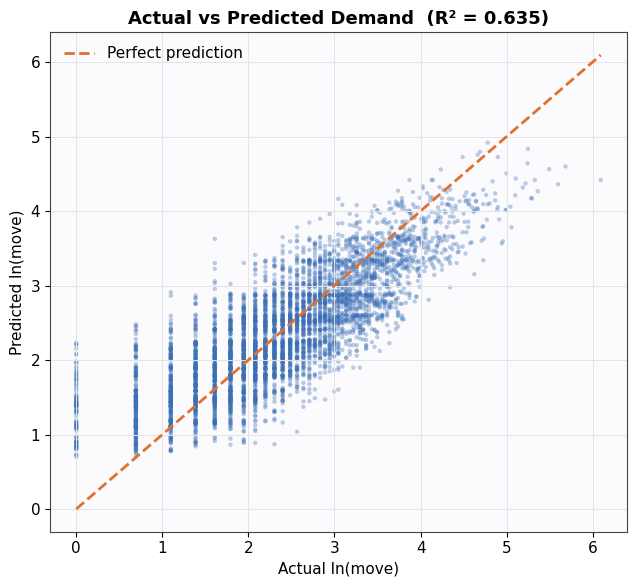

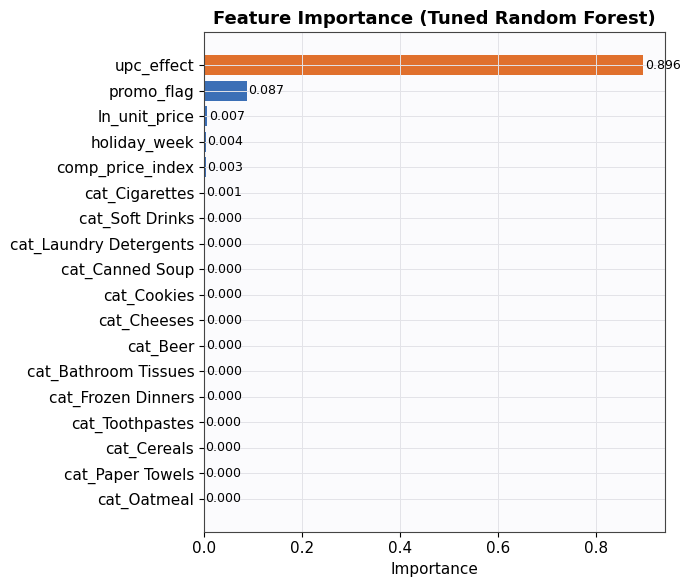

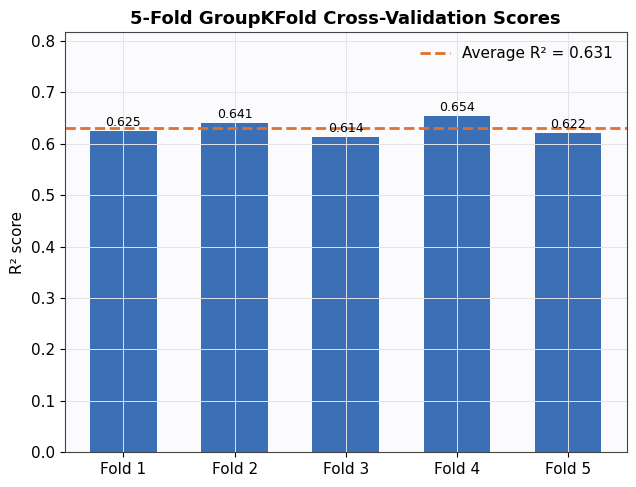


Saved: rf_v2_results.txt
Saved: plot1_actual_vs_predicted.png, plot2_feature_importance.png, plot3_cv_scores.png


In [1]:
import sys, os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

# ---- nice plot style ----
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#fbfbfd",
    "axes.edgecolor": "#444444", "axes.grid": True, "grid.color": "#e3e3e8",
    "grid.linewidth": 0.7, "font.size": 11, "axes.titlesize": 13,
    "axes.titleweight": "bold", "axes.labelsize": 11,
})
PRIMARY, ACCENT = "#3b6fb6", "#e0702d"

# ---------------- load data ----------------
NEED_COLS = ["ln_unit_price", "ln_move", "promo_flag", "holiday_week",
             "comp_price_index", "category", "upc", "ok"]
df = pd.read_csv(PATH, usecols=NEED_COLS)
df = df[df.ok == 1].copy()
del df["ok"]

SAMPLE_N = 80_000
if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
gc.collect()

y = df["ln_move"]
groups = df["upc"]  # GroupKFold isi column ke hisab se split karega

# ---- upc_effect ko poore sample par nikalte hain (CV ke andar fold-wise bhi
# ek version banayenge taake leakage na ho, lekin final model ke liye yahan
# overall version use karte hain) ----
upc_mean_full = df.groupby("upc")["ln_move"].transform("mean")

cat_dummies = pd.get_dummies(df["category"], prefix="cat", drop_first=True)
X = pd.concat([df[["ln_unit_price", "promo_flag", "holiday_week", "comp_price_index"]],
               upc_mean_full.rename("upc_effect"), cat_dummies], axis=1)

print(f"Target column: ln_move | Total input columns: {X.shape[1]}")

# ============================================================
# PART 1: GROUPKFOLD CROSS-VALIDATION (baseline model ke sath)
# ============================================================
print("\n" + "=" * 70)
print("PART 1: 5-FOLD GroupKFold CROSS-VALIDATION (grouped by upc)")
print("=" * 70)

gkf = GroupKFold(n_splits=5)
baseline_model = RandomForestRegressor(n_estimators=40, max_depth=8,
                                        min_samples_leaf=20, random_state=42, n_jobs=2)

cv_r2, cv_mae = [], []
for fold, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):
    baseline_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    pred = baseline_model.predict(X.iloc[te_idx])
    r2 = r2_score(y.iloc[te_idx], pred)
    mae = mean_absolute_error(y.iloc[te_idx], pred)
    cv_r2.append(r2)
    cv_mae.append(mae)
    print(f"  Fold {fold}: R2 = {r2:.4f} | MAE = {mae:.4f}")

print(f"\nAverage R2  : {np.mean(cv_r2):.4f}  (+/- {np.std(cv_r2):.4f})")
print(f"Average MAE : {np.mean(cv_mae):.4f}  (+/- {np.std(cv_mae):.4f})")

# ============================================================
# PART 2: HYPERPARAMETER TUNING (RandomizedSearchCV)
# ============================================================
print("\n" + "=" * 70)
print("PART 2: HYPERPARAMETER TUNING (RandomizedSearchCV, 3-fold GroupKFold)")
print("=" * 70)

# Tuning ke liye ek chhota subsample use karte hain (speed ke liye) -- final
# model ko phir poore sample (X, y) par train karenge best params ke sath.
tune_idx = np.random.default_rng(42).choice(len(X), size=min(40_000, len(X)), replace=False)
X_tune, y_tune, groups_tune = X.iloc[tune_idx], y.iloc[tune_idx], groups.iloc[tune_idx]

param_grid = {
    "n_estimators": [40, 80, 120],
    "max_depth": [8, 12, 16],
    "min_samples_leaf": [10, 20, 40],
    "max_features": ["sqrt", 0.6],
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=2),
    param_distributions=param_grid,
    n_iter=5,                        # 5 random combinations try karega (fast)
    cv=GroupKFold(n_splits=2),
    scoring="r2",
    random_state=42,
    n_jobs=1,                        # memory bachane ke liye sequential
)
search.fit(X_tune, y_tune, groups=groups_tune)

print("Best parameters found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV R2: {search.best_score_:.4f}")

best_model = search.best_estimator_

# ============================================================
# PART 3: FINAL MODEL -- hold-out test set par evaluate + PLOTS
# ============================================================
print("\n" + "=" * 70)
print("PART 3: FINAL MODEL (tuned) -- hold-out test set par evaluation")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
best_model.fit(X_train, y_train)
pred_test = best_model.predict(X_test)

final_r2 = r2_score(y_test, pred_test)
final_mae = mean_absolute_error(y_test, pred_test)
final_rmse = np.sqrt(mean_squared_error(y_test, pred_test))
print(f"Final R2  : {final_r2:.4f}")
print(f"Final MAE : {final_mae:.4f}")
print(f"Final RMSE: {final_rmse:.4f}")

# ---------------- PLOT 1: Actual vs Predicted ----------------
fig, ax = plt.subplots(figsize=(6.5, 6))
idx = np.random.default_rng(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
ax.scatter(y_test.values[idx], pred_test[idx], s=10, alpha=0.35, color=PRIMARY, edgecolors="none")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
ax.plot(lims, lims, color=ACCENT, lw=2, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Actual ln(move)")
ax.set_ylabel("Predicted ln(move)")
ax.set_title(f"Actual vs Predicted Demand  (R² = {final_r2:.3f})")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("plot1_actual_vs_predicted.png", dpi=130)
plt.show()

# ---------------- PLOT 2: Feature Importance ----------------
importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 6))
colors = [ACCENT if v == importance.max() else PRIMARY for v in importance.values]
ax.barh(importance.index, importance.values, color=colors)
ax.set_xlabel("Importance")
ax.set_title("Feature Importance (Tuned Random Forest)")
for i, v in enumerate(importance.values):
    ax.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("plot2_feature_importance.png", dpi=130)
plt.show()

# ---------------- PLOT 3: CV scores across folds ----------------
fig, ax = plt.subplots(figsize=(6.5, 5))
folds = [f"Fold {i+1}" for i in range(len(cv_r2))]
bars = ax.bar(folds, cv_r2, color=PRIMARY, width=0.6)
ax.axhline(np.mean(cv_r2), color=ACCENT, linestyle="--", lw=2,
           label=f"Average R² = {np.mean(cv_r2):.3f}")
for b, v in zip(bars, cv_r2):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("R² score")
ax.set_title("5-Fold GroupKFold Cross-Validation Scores")
ax.set_ylim(0, max(cv_r2) * 1.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("plot3_cv_scores.png", dpi=130)
plt.show()

# ---------------- save text summary ----------------
with open("rf_v2_results.txt", "w") as f:
    f.write(f"Target: ln_move | Predictors ({X.shape[1]}): {list(X.columns)}\n\n")
    f.write("GroupKFold CV (baseline params):\n")
    for i, (r2, mae) in enumerate(zip(cv_r2, cv_mae), 1):
        f.write(f"  Fold {i}: R2={r2:.4f}, MAE={mae:.4f}\n")
    f.write(f"  Average R2: {np.mean(cv_r2):.4f} (+/- {np.std(cv_r2):.4f})\n\n")
    f.write(f"Best hyperparameters: {search.best_params_}\n")
    f.write(f"Best CV R2 (tuning): {search.best_score_:.4f}\n\n")
    f.write(f"Final tuned model on hold-out test set:\n")
    f.write(f"  R2: {final_r2:.4f}\n  MAE: {final_mae:.4f}\n  RMSE: {final_rmse:.4f}\n")

print("\nSaved: rf_v2_results.txt")
print("Saved: plot1_actual_vs_predicted.png, plot2_feature_importance.png, plot3_cv_scores.png")

In [3]:
import sys, os, gc
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

NEED_COLS = ["ln_unit_price", "ln_move", "move", "unit_price", "promo_flag",
             "holiday_week", "comp_price_index", "category", "upc", "brand",
             "store", "week", "ok"]
df = pd.read_csv(PATH, usecols=NEED_COLS)
df = df[df.ok == 1].copy()

SAMPLE_N = 80_000
if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
gc.collect()

y = df["ln_move"]
upc_mean_full = df.groupby("upc")["ln_move"].transform("mean")
cat_dummies = pd.get_dummies(df["category"], prefix="cat", drop_first=True)
X = pd.concat([df[["ln_unit_price", "promo_flag", "holiday_week", "comp_price_index"]],
               upc_mean_full.rename("upc_effect"), cat_dummies], axis=1)

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=20,
                               random_state=42, n_jobs=2)
model.fit(X_train, y_train)
pred_log = model.predict(X_test)

# ---- YAHAN ASAL KAAM HO RAHA HAI: log se wapis plain units mein convert karna ----
# ln_move = log(move), is liye move = exp(ln_move)
actual_units = np.round(np.exp(y_test.values)).astype(int)
predicted_units = np.round(np.exp(pred_log)).astype(int)

result = pd.DataFrame({
    "store": df_test["store"].values,
    "category": df_test["category"].values,
    "brand": df_test["brand"].values,
    "unit_price_dollars": df_test["unit_price"].round(2).values,
    "promo": np.where(df_test["promo_flag"].values == 1, "Yes", "No"),
    "ACTUAL_units_sold": actual_units,
    "PREDICTED_units_sold": predicted_units,
    "difference": actual_units - predicted_units,
})
result["error_pct"] = (result["difference"].abs() / result["ACTUAL_units_sold"].replace(0, 1) * 100).round(1)

pd.set_option("display.width", 200, "display.max_columns", 20)
print("=" * 100)
print("REAL-WORLD PREDICTIONS -- model ne kya predict kiya (sample 20 rows)")
print("=" * 100)
print(result.head(20).to_string(index=False))

print("\n" + "=" * 100)
print("OVERALL ACCURACY (plain units mein)")
print("=" * 100)
print(f"Average actual units sold    : {result['ACTUAL_units_sold'].mean():.1f}")
print(f"Average predicted units sold : {result['PREDICTED_units_sold'].mean():.1f}")
print(f"Average error (units)        : {result['difference'].abs().mean():.2f}")
print(f"Average error (%)            : {result['error_pct'].mean():.1f}%")
print(f"Predictions within +/-2 units of actual: "
      f"{(result['difference'].abs() <= 2).mean()*100:.1f}% of rows")

result.to_csv("real_world_predictions.csv", index=False)
print("\nSaved: real_world_predictions.csv (poori test set, readable format mein)")

REAL-WORLD PREDICTIONS -- model ne kya predict kiya (sample 20 rows)
 store           category        brand  unit_price_dollars promo  ACTUAL_units_sold  PREDICTED_units_sold  difference  error_pct
     5            Cereals      Colgate                4.50    No                  3                     7          -4      133.3
    60   Bathroom Tissues      Tylenol                2.97    No                  8                     6           2       25.0
    63        Canned Soup      Kellogg                1.79    No                 11                    14          -3       27.3
    56        Soft Drinks      Nabisco                4.30    No                  1                     4          -3      300.0
    11        Canned Soup     Marlboro                0.94    No                  5                     4           1       20.0
    32 Laundry Detergents        Heinz                9.56    No                 12                    11           1        8.3
   100        Canned Soup   

MODEL COMPARISON
Random Forest                : R2 = 0.6333  MAE = 0.4545
XGBoost                      : R2 = 0.6354  MAE = 0.4531
XGBoost + Calibration        : R2 = 0.6350  MAE = 0.4534

LOW-demand rows (bottom 10%) par average error (bias):
  Random Forest        : +0.936
  XGBoost + Calibration: +0.920

HIGH-demand rows (top 10%) par average error (bias):
  Random Forest        : -0.468
  XGBoost + Calibration: -0.454


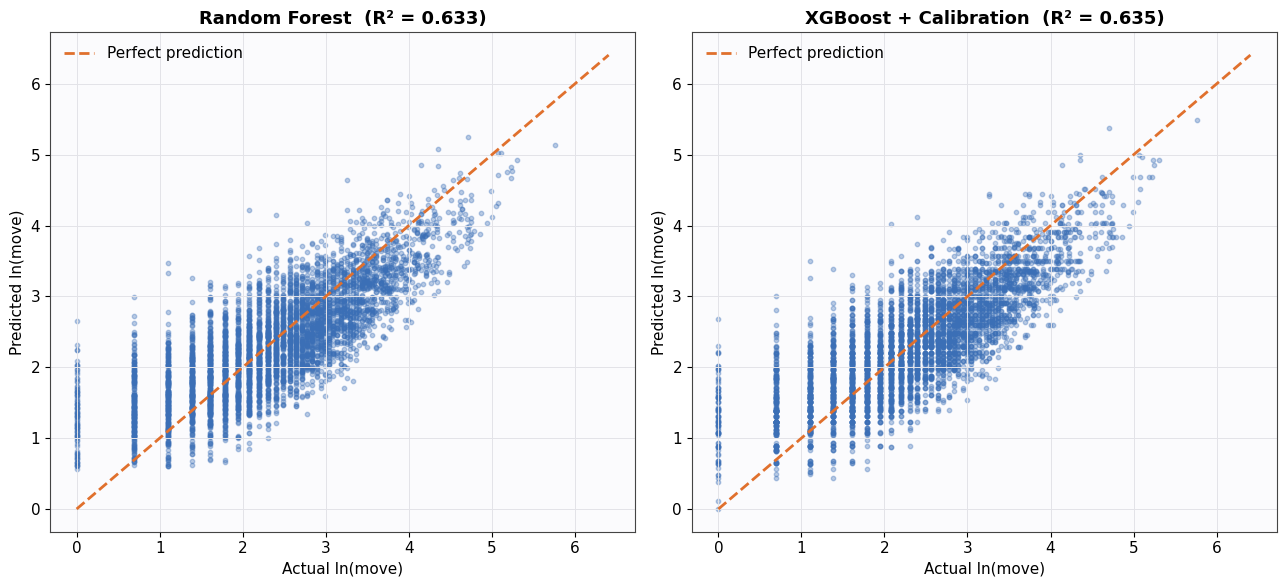


Saved: plot_comparison_rf_vs_xgb.png, xgb_results.txt


In [4]:
import sys, os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.isotonic import IsotonicRegression
import xgboost as xgb

DEFAULT_PATH = "/kaggle/input/datasets/ib2him/snhadj/dominicks_style_merged.csv"
if len(sys.argv) > 1 and os.path.isfile(sys.argv[1]):
    PATH = sys.argv[1]
else:
    PATH = DEFAULT_PATH

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "#fbfbfd",
                      "axes.grid": True, "grid.color": "#e3e3e8", "font.size": 11,
                      "axes.titlesize": 13, "axes.titleweight": "bold"})
PRIMARY, ACCENT, GREEN = "#3b6fb6", "#e0702d", "#2f9e44"

NEED_COLS = ["ln_unit_price", "ln_move", "promo_flag", "holiday_week",
             "comp_price_index", "category", "upc", "ok"]
df = pd.read_csv(PATH, usecols=NEED_COLS)
df = df[df.ok == 1].copy()

SAMPLE_N = 150_000
if len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=42).reset_index(drop=True)
gc.collect()

y = df["ln_move"]
upc_mean_full = df.groupby("upc")["ln_move"].transform("mean")
cat_dummies = pd.get_dummies(df["category"], prefix="cat", drop_first=True)
X = pd.concat([df[["ln_unit_price", "promo_flag", "holiday_week", "comp_price_index"]],
               upc_mean_full.rename("upc_effect"), cat_dummies], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==================== Model 1: Random Forest (purana baseline) ====================
rf = RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=20,
                            random_state=42, n_jobs=2)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, pred_rf)

# ==================== Model 2: XGBoost (Gradient Boosting) ====================
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=2,
)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, pred_xgb)

# ==================== Model 3: XGBoost + Calibration ====================
# Pehle train data par predict karte hain, phir dekhte hain predictions mein
# kya systematic bias hai (jaise high values kam predict hoti hain). Isotonic
# Regression ye bias seekh kar correction laga deta hai.
pred_xgb_train = xgb_model.predict(X_train)
calibrator = IsotonicRegression(out_of_bounds="clip")
calibrator.fit(pred_xgb_train, y_train)
pred_xgb_calibrated = calibrator.predict(pred_xgb)
r2_calibrated = r2_score(y_test, pred_xgb_calibrated)

# ==================== Results ====================
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(f"Random Forest                : R2 = {r2_rf:.4f}  MAE = {mean_absolute_error(y_test, pred_rf):.4f}")
print(f"XGBoost                      : R2 = {r2_xgb:.4f}  MAE = {mean_absolute_error(y_test, pred_xgb):.4f}")
print(f"XGBoost + Calibration        : R2 = {r2_calibrated:.4f}  MAE = {mean_absolute_error(y_test, pred_xgb_calibrated):.4f}")

# ---- extremes par specifically kitna behtar hua, ye check karte hain ----
low_mask = y_test < y_test.quantile(0.10)   # sab se kam demand wale 10%
high_mask = y_test > y_test.quantile(0.90)  # sab se zyada demand wale 10%

print("\nLOW-demand rows (bottom 10%) par average error (bias):")
print(f"  Random Forest        : {(pred_rf[low_mask] - y_test[low_mask]).mean():+.3f}")
print(f"  XGBoost + Calibration: {(pred_xgb_calibrated[low_mask] - y_test[low_mask]).mean():+.3f}")

print("\nHIGH-demand rows (top 10%) par average error (bias):")
print(f"  Random Forest        : {(pred_rf[high_mask] - y_test[high_mask]).mean():+.3f}")
print(f"  XGBoost + Calibration: {(pred_xgb_calibrated[high_mask] - y_test[high_mask]).mean():+.3f}")

# ==================== Plot: side-by-side comparison ====================
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
idx = np.random.default_rng(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)
lims = [y_test.min(), y_test.max()]

for ax, pred, title, r2 in [
    (axes[0], pred_rf, "Random Forest", r2_rf),
    (axes[1], pred_xgb_calibrated, "XGBoost + Calibration", r2_calibrated),
]:
    ax.scatter(y_test.values[idx], np.array(pred)[idx], s=10, alpha=0.35, color=PRIMARY)
    ax.plot(lims, lims, color=ACCENT, lw=2, linestyle="--", label="Perfect prediction")
    ax.set_xlabel("Actual ln(move)")
    ax.set_ylabel("Predicted ln(move)")
    ax.set_title(f"{title}  (R² = {r2:.3f})")
    ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("plot_comparison_rf_vs_xgb.png", dpi=130)
plt.show()

with open("xgb_results.txt", "w") as f:
    f.write(f"Random Forest R2: {r2_rf:.4f}\nXGBoost R2: {r2_xgb:.4f}\n"
            f"XGBoost+Calibration R2: {r2_calibrated:.4f}\n")

print("\nSaved: plot_comparison_rf_vs_xgb.png, xgb_results.txt")